# Fake Job Posting Detection — Exploratory Data Analysis

This notebook performs an exploratory data analysis (EDA) on the **Real or Fake Job Postings** dataset (Kaggle). The goal is to understand the structure of the data, identify patterns that distinguish fraudulent from legitimate postings, and extract insights that will inform our modelling pipeline.

The project pipeline consists of: Problem Formulation → Data Preparation → Pre-processing → **EDA** → Modelling → Evaluation.

---

## 1. Dataset Overview

We begin by loading the dataset and inspecting its basic properties: shape, column types, and summary statistics. This gives us a high-level understanding of what we are working with before diving deeper.

In [2]:
import pandas as pd

df = pd.read_csv("merged_job_postings.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17977 entries, 0 to 17976
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               17977 non-null  float64
 1   title                17976 non-null  object 
 2   location             17937 non-null  object 
 3   department           17977 non-null  object 
 4   salary_range         17977 non-null  object 
 5   company_profile      17976 non-null  object 
 6   description          17977 non-null  object 
 7   requirements         17880 non-null  object 
 8   benefits             17880 non-null  object 
 9   telecommuting        17977 non-null  float64
 10  has_company_logo     17977 non-null  float64
 11  has_questions        17977 non-null  float64
 12  employment_type      17977 non-null  object 
 13  required_experience  17880 non-null  object 
 14  required_education   17880 non-null  object 
 15  industry             17975 non-null 

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17977.000000,17977.000000,17977.000000,17977.000000,17977.000000
mean,8892.258998,0.042666,0.791011,0.489069,0.048173
std,5189.211806,0.202108,0.406598,0.499894,0.214137
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4398.000000,0.000000,1.000000,0.000000,0.000000
50%,8892.000000,0.000000,1.000000,0.000000,0.000000
75%,13386.000000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


**Key observations:**

- The dataset contains **17,977 job postings** across **18 columns**, mixing text features (e.g. `description`, `title`) with binary/categorical flags.
- Only numeric columns (`job_id`, `telecommuting`, `has_company_logo`, `has_questions`, `fraudulent`) are captured by `describe()`. The remaining 13 columns are object (string) types.
- The `fraudulent` column is our **target variable** (0 = real, 1 = fake).

---

## 2. Class Distribution

Understanding class balance is critical before any classification task. Here we examine how many postings are real versus fraudulent.

In [5]:
df['fraudulent'].value_counts()
df['fraudulent'].value_counts(normalize=True)

fraudulent
0    0.951827
1    0.048173
Name: proportion, dtype: float64

**Insight:** The dataset is heavily **imbalanced** — only ~**4.8 %** of postings are labelled as fraudulent. This means a naïve classifier that always predicts 'real' would achieve ~95 % accuracy. When building models we must account for this imbalance (e.g. via class weighting, over/under-sampling, or choosing appropriate evaluation metrics such as F1-score and AUC-ROC).

The bar chart below makes the imbalance visually apparent.

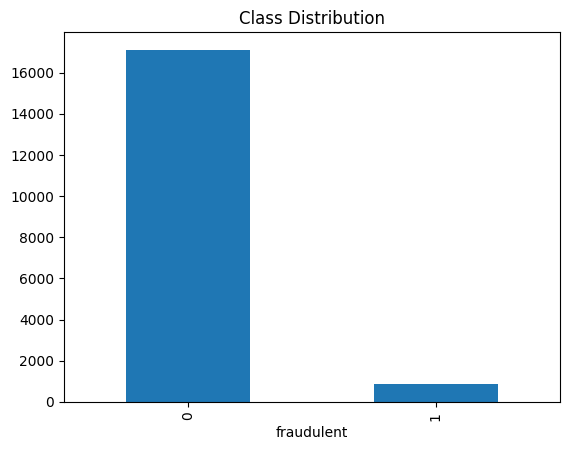

In [8]:
import matplotlib.pyplot as plt

df['fraudulent'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

---

## 3. Missing Value Analysis

Before any modelling or feature engineering we need to understand where data is absent. Missing values can affect model performance and may themselves carry information (e.g. a missing `company_profile` could be a signal of a fraudulent posting).

In [10]:
df.isnull().sum().sort_values(ascending=False)

requirements           97
benefits               97
function               97
required_experience    97
required_education     97
location               40
industry                2
title                   1
company_profile         1
job_id                  0
telecommuting           0
description             0
department              0
salary_range            0
employment_type         0
has_questions           0
has_company_logo        0
fraudulent              0
dtype: int64

**Insight:** Several columns have a non-trivial proportion of missing values:

- `requirements`, `benefits`, `function`, `required_experience`, `required_education` — each missing **97** values (~0.5 %)
- `location` — missing **40** values
- `industry`, `title`, `company_profile` — very few missing values

Critically, `description` and `fraudulent` have **no missing values**, so our primary text feature and target label are complete. Columns with a high missing rate may need to be imputed or dropped depending on the downstream model.

The heatmap below provides a spatial overview of missingness across the dataset.

<Axes: >

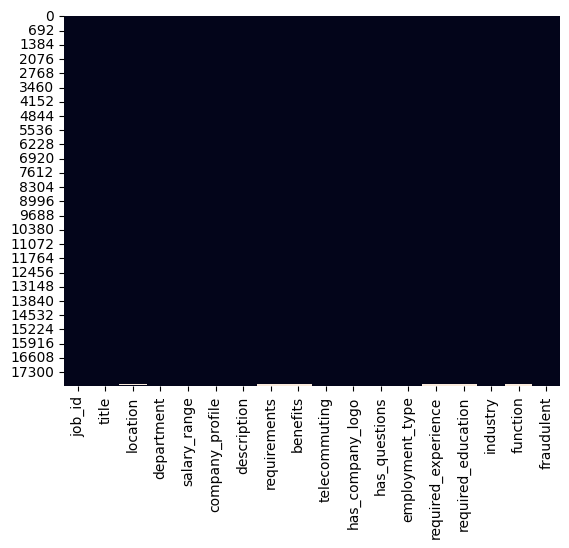

In [13]:
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False)

---

## 4. Text Length Analysis

Fraudulent postings may differ from real ones in how much text they contain. A very short or very long description could be a signal. We compute the character-level length of each job description and compare the means for real vs. fraudulent postings.

In [15]:
df['desc_length'] = df['description'].astype(str).apply(len)

df.groupby('fraudulent')['desc_length'].mean()

fraudulent
0    1232.482380
1    1154.836028
Name: desc_length, dtype: float64

**Insight:** Real job postings (label 0) have a slightly **longer** average description (~1,232 characters) compared to fraudulent ones (~1,155 characters). The difference is modest, suggesting that description length alone is not a strong discriminator — but it may still contribute as a feature in combination with others.

The histogram below shows the full distribution of description lengths, split by class.

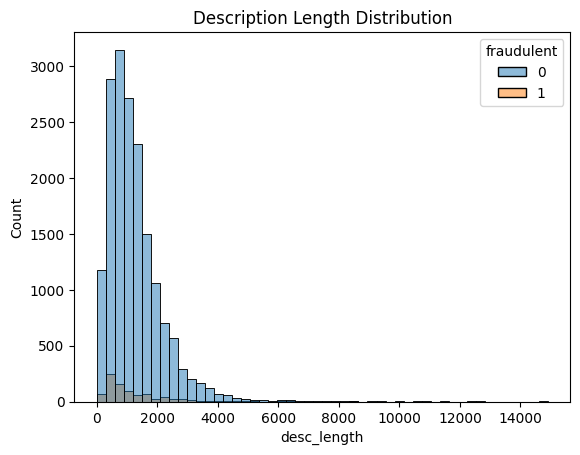

In [18]:
sns.histplot(data=df, x='desc_length', hue='fraudulent', bins=50)
plt.title("Description Length Distribution")
plt.show()

The distributions overlap considerably, confirming that length is a weak signal on its own. However, the right tail (very long descriptions) appears more common in real postings.

---

## 5. Word Frequency Analysis

We tokenise the job descriptions and compare the most frequently occurring words in real vs. fraudulent postings. This is a core NLP EDA step — it helps us understand the vocabulary each class uses and can reveal informative keywords for classification. 
> **Note:** The output below shows the top-20 words for **fake** postings (the last expression evaluated). The same logic runs for real postings in the same cell.

In [21]:
from collections import Counter
import re

def get_words(text):
    words = re.findall(r'\w+', str(text).lower())
    return words

real_words = []
fake_words = []

for _, row in df.iterrows():
    words = get_words(row['description'])
    if row['fraudulent'] == 0:
        real_words.extend(words)
    else:
        fake_words.extend(words)

Counter(real_words).most_common(20)
Counter(fake_words).most_common(20)

[('and', 8017),
 ('to', 4472),
 ('the', 4313),
 ('of', 2767),
 ('a', 2362),
 ('in', 2234),
 ('for', 2158),
 ('with', 1767),
 ('are', 1217),
 ('is', 1163),
 ('we', 1083),
 ('work', 1052),
 ('you', 1040),
 ('on', 899),
 ('or', 803),
 ('as', 798),
 ('our', 724),
 ('be', 709),
 ('amp', 695),
 ('will', 631)]

**Insight:** At this stage, the most common words are largely **stop words** (e.g. 'and', 'to', 'the'). These will be removed during the pre-processing stage. After stop-word removal we expect to see more meaningful vocabulary differences between classes — for example, fraudulent postings often contain vague or overly-promotional language.

---

## 6. Word Cloud Visualisation

Word clouds provide an intuitive visual summary of the most frequent terms in each class. We generate separate word clouds for real and fake job postings.

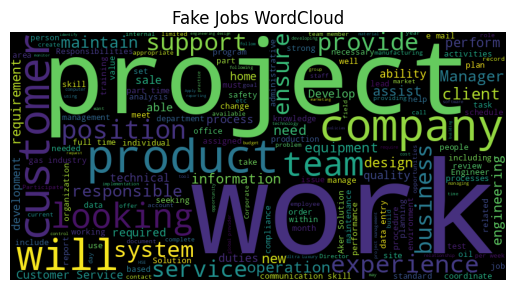

In [24]:
from wordcloud import WordCloud

fake_text = " ".join(df[df['fraudulent']==1]['description'].astype(str))
real_text = " ".join(df[df['fraudulent']==0]['description'].astype(str))

wc = WordCloud(width=800, height=400).generate(fake_text)
plt.imshow(wc)
plt.axis('off')
plt.title("Fake Jobs WordCloud")
plt.show()

---

## 7. Categorical Feature Analysis

Beyond text, the dataset contains several categorical features such as `employment_type`. We examine their distributions and check whether certain categories are disproportionately associated with fraudulent postings.

In [26]:
df['employment_type'].value_counts()

employment_type
Full-time    11717
0             3471
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

**Observation:** The majority of postings are **Full-time**, followed by a large 'unspecified' category (coded as `0`). Contract, Part-time, Temporary, and Other are much less common.

The grouped bar chart below splits each employment type by the `fraudulent` label.

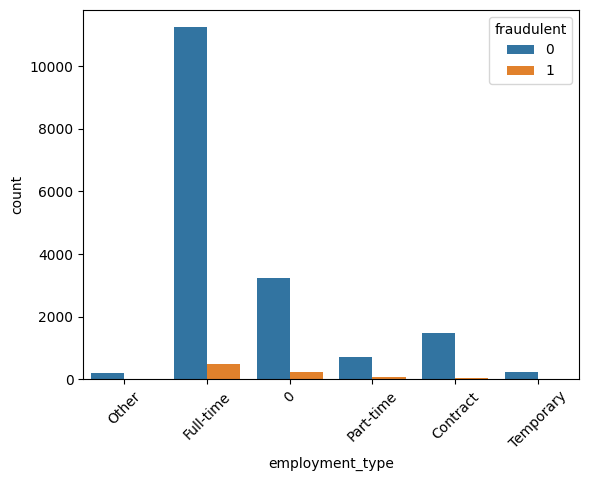

In [29]:
sns.countplot(data=df, x='employment_type', hue='fraudulent')
plt.xticks(rotation=45)
plt.show()

**Insight:** Fraudulent postings appear across all employment types. Postings that do **not** specify an employment type (coded `0`) seem to have a somewhat higher proportion of fraud, which makes intuitive sense — legitimate employers are more likely to specify the type of role.

---

## 8. Correlation Analysis (Numeric Features)

We compute pairwise Pearson correlations between all numeric columns. This gives a quick view of linear relationships — in particular, any numeric features that correlate with the target `fraudulent`.

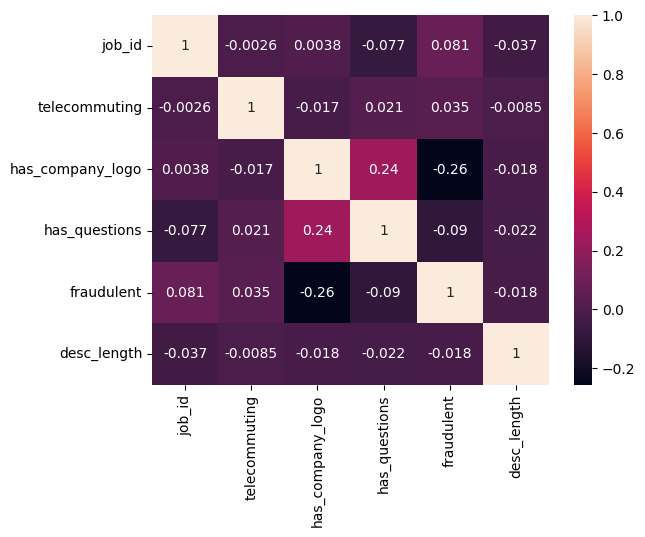

In [32]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

**Insight:** The numeric correlations with `fraudulent` are generally low, confirming that the classification signal is largely **encoded in the text** rather than in the structured fields. This motivates a strong focus on NLP-based features (TF-IDF, word embeddings, etc.) in the modelling stage.

---

## 9. Bi-gram (N-gram) Analysis

Single words can be ambiguous; looking at **bi-grams** (two-word phrases) often reveals more meaningful patterns. We use `CountVectorizer` with `ngram_range=(2,2)` to find the most common two-word sequences in the descriptions, after removing English stop words.

In [35]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
X = vectorizer.fit_transform(df['description'].astype(str))

sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

words_freq[:20]

[('customer service', np.int64(2863)),
 ('social media', np.int64(1502)),
 ('join team', np.int64(1109)),
 ('team members', np.int64(1105)),
 ('fast paced', np.int64(1071)),
 ('communication skills', np.int64(1056)),
 ('ideal candidate', np.int64(989)),
 ('responsibilities include', np.int64(930)),
 ('day day', np.int64(876)),
 ('years experience', np.int64(852)),
 ('work closely', np.int64(825)),
 ('fast growing', np.int64(818)),
 ('business development', np.int64(787)),
 ('student loans', np.int64(729)),
 ('loans credit', np.int64(726)),
 ('cost living', np.int64(724)),
 ('monthly 200', np.int64(720)),
 ('200 cost', np.int64(720)),
 ('play kids', np.int64(715)),
 ('kids paid', np.int64(715))]

**Insight:** Several suspicious bi-grams appear prominently, including phrases related to financial hardship ('student loans', 'loans credit', 'cost living', 'monthly 200') and generic recruiting language ('join team', 'fast paced', 'ideal candidate'). These repeated patterns in fraudulent postings can be powerful features for a text classifier.

---

## Summary of EDA Findings

| Finding | Implication |
|---|---|
| Dataset is highly imbalanced (~4.8 % fraud) | Use F1/AUC metrics; consider class weighting |
| Several columns have missing values | Impute or drop before modelling |
| Description length weakly differs between classes | Include as an auxiliary feature |
| Numeric correlations with fraud are low | Focus on text-based features |
| Distinctive bi-grams in fraudulent postings | TF-IDF / n-gram features likely very informative |

The next stage of the project will use these insights to guide **pre-processing** and **feature engineering** before training and comparing at least three classification models.